The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Epoch 0 with train loss: 0.3501940268278122 and eval loss: 0.15696317265215126
Epoch 1 with train loss: 0.19159183909495672 and eval loss: 0.1400560258847216
Epoch 2 with train loss: 0.16865966151158016 and eval loss: 0.13341165131524854
Epoch 3 with train loss: 0.16186614582935968 and eval loss: 0.13704011403024197
Epoch 4 with train loss: 0.15630191067854562 and eval loss: 0.130014025322769
Epoch 5 with train loss: 0.14894687841335932 and eval loss: 0.1288535590486034
Epoch 6 with train loss: 0.14458020399014154 and eval loss: 0.13179815066573414
Epoch 7 with train loss: 0.14303200940291086 and eval loss: 0.14233421275149222
Epoch 8 with train loss: 0.14391664654016495 and eval loss: 0.14058353808587012
Epoch 9 with train loss: 0.14116895844539007 and eval loss: 0.1338860119652489
Epoch 10 with train loss: 0.13932911773522694 and eval loss: 0.1343187704358412
Epoch 11 with train loss: 0.1402962609

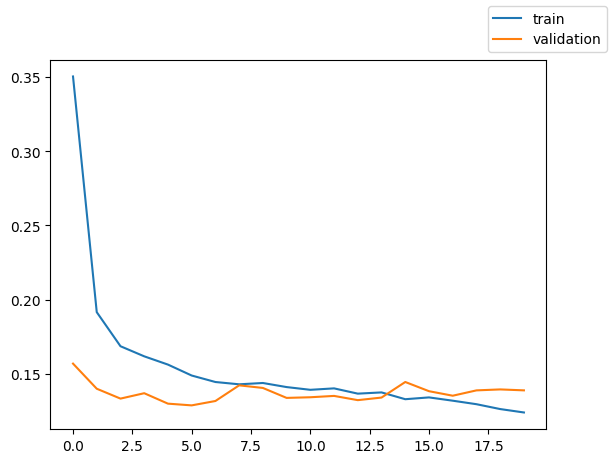

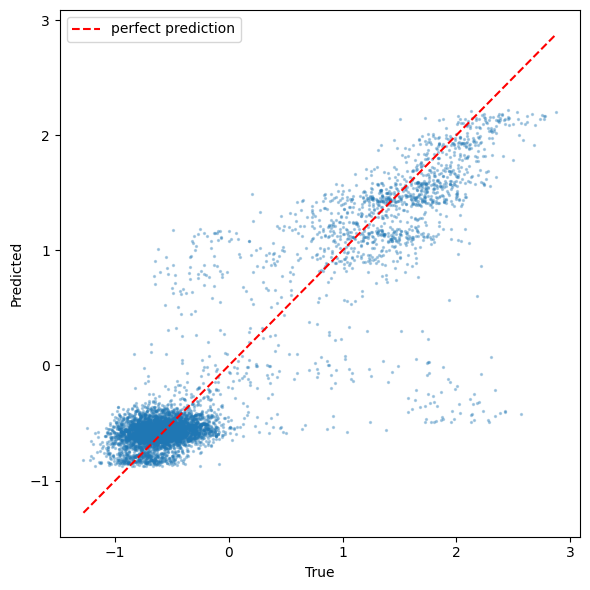

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import pickle

%load_ext autoreload
%autoreload 2

from data_helpers import prepare_this_data, torchify_this_data
from model_stuff import model_setup

df = pd.read_csv('../data/CESMDataset_Try.csv')

target_col = 'SFWF'
feature_cols = ['AMOC', 'PD_200m']
lag = 100
horizon = 40
n = len(df)
train_cut_1 = 5000
train_cut_2 = 11000
batch_size = 128

X_train_lag, y_train_lag, X_eval_lag, y_eval_lag, y_scaler, x_scaler = prepare_this_data(df, 
                                                                                        target_col, 
                                                                                        feature_cols,
                                                                                        train_cut_1,
                                                                                        train_cut_2,
                                                                                        lag,
                                                                                        horizon)

X_train_t, y_train_t, train_loader, X_eval_t, y_eval_t, eval_loader = torchify_this_data(batch_size, 
                                                                                        X_train_lag, 
                                                                                        y_train_lag,                                                                                                                       
                                                                                        X_eval_lag, 
                                                                                        y_eval_lag)
device = "cpu"
n_epochs = 20

params = {
    'n_features': len(feature_cols),
    'hidden_size': 64,
    'num_layers': 1,
    'dropout': 0.0,
    'lr': 1e-3,
    'loss_fn': nn.MSELoss()
}

NN_SFWF, train_losses, eval_losses = model_setup(device, params, n_epochs, train_loader, eval_loader, X_eval_t, y_eval_lag)

torch.save({
    'state_dict': NN_SFWF.state_dict(),
    'config': {
        'n_features': len(feature_cols),
        'hidden_size': 64,
        'num_layers': 1,
        'dropout': 0.0,
    },
}, 'SFWF_model.pth')

with open('scalers_SFWF.pkl', 'wb') as f:
    pickle.dump({'y_scaler': y_scaler, 'x_scaler': x_scaler}, f)
